# Reported-date relationship stability

Nine reproducible figures from the frozen 545 diagnostic / 480 ratio pairs. Details belong in the notes below each chart. Reported dates do not establish active sampling intervals.

In [1]:
import sys
# For notebooks inside research/ftir_hips_chem/:
sys.path.insert(0, './scripts')
# For notebooks under notebooks/ (e.g. plotting_gaps_scenarios.ipynb):
# sys.path.insert(0, '../research/ftir_hips_chem/scripts')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Config + data
from config import (
    SITES, PROCESSED_SITES_DIR, FILTER_DATA_PATH,
    AERONET_DATA_DIR, WEATHER_DATA_DIR, MAC_VALUE,
)

# Exclusions (use these — do not hand-filter)
from outliers import (
    EXCLUDED_SAMPLES, MANUAL_OUTLIERS,
    apply_exclusion_flags, apply_threshold_flags,
    get_clean_data, print_exclusion_summary,
)

# Data loading / matching
from data_matching import (
    load_aethalometer_data, load_filter_data,
    match_aeth_filter_data, match_all_parameters,
)
from etad_factors import load_etad_factor_contributions, match_etad_factors

# External datasets — these resolve their own location, so do NOT hardcode a
# Drive path. Each checks an env var, then a config constant, then discovers the
# Drive mount: AETHMODULAR_AERONET_DIR / AETHMODULAR_IMPROVE_DIR.
from aeronet import load_aeronet, aeronet_dir, COLS as AERONET_COLS
from improve_io import load_improve_clean

# Plotting — importing the package auto-applies the white-background default
# style (apply_default_style()). Do NOT call plt.style.use('seaborn-v0_8-darkgrid')
# afterwards — it re-adds the grey axes facecolor we don't want.
from plotting import PlotConfig, crossplots, timeseries, distributions, comparisons
from plotting.utils import calculate_regression_stats

PlotConfig.set(sites='all', layout='individual', show_stats=False, show_1to1=False)


The standard exclusion flow was applied when the baseline was built. This notebook deliberately uses the frozen values, identity-linked flags and saved memberships, verified by hash. Reapplying newly changed rules would alter the estimand.

In [2]:
from pathlib import Path
import importlib.util
from IPython.display import display
path=Path('workflows/analyze_filter_relationship_stability.py').resolve()
spec=importlib.util.spec_from_file_location('stability_workflow',path)
workflow=importlib.util.module_from_spec(spec)
spec.loader.exec_module(workflow)
tables, figure_paths=workflow.run_analysis()
b=tables['block_performance_and_influence']
p=tables['heldout_filter_predictions']
c=tables['full_cohort_coefficients']
s=tables['performance_summary']
inf=tables['ETAD_0037_paired_influence']
cohorts=tables['population_membership_summary']
from plotting import filter_relationship_stability as charts

       site            scheme  evaluated_filters  improved_blocks  evaluated_blocks  median_mae   ols_mae  ols_mean_signed_error
Addis_Ababa leave_quarter_out                190                8                 8    8.887554  3.938429               0.024691
Addis_Ababa      later_period                155                6                 6    9.332030  4.274422               2.256478
    Beijing leave_quarter_out                163                7                 9    5.637571  3.563054               0.000009
    Beijing      later_period                132                6                 7    5.198385  3.610006               0.967303
      Delhi leave_quarter_out                 62                5                 5   28.889501 14.533532              -1.778791
      Delhi      later_period                 38                2                 3   31.149934 15.934421             -15.298338
        JPL leave_quarter_out                130                6                 6    1.744450  

## Withheld-block errors

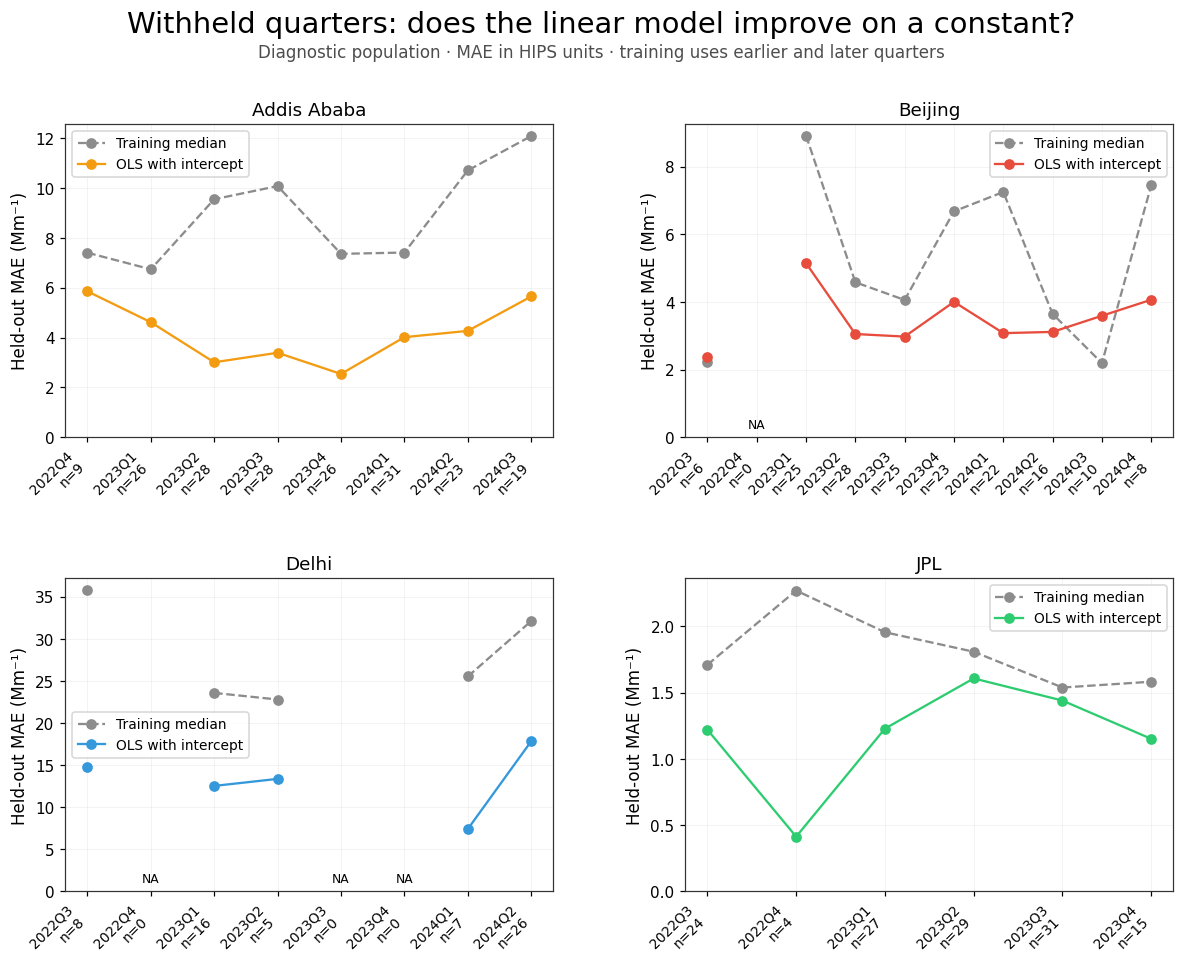

In [3]:
fig = charts.mae_blocks(b,'leave_quarter_out')
display(fig)
plt.close(fig)

**Notes.** Addis improves on the training median in all eight quarters, with MAE 3.94 versus 8.89 Mm⁻¹. Training here includes later as well as earlier filters; this is within-record stability. Delhi/JPL also improve in every diagnostic block; Beijing has two exceptions. Each site uses its own vertical scale.

## Bias across reported-date blocks

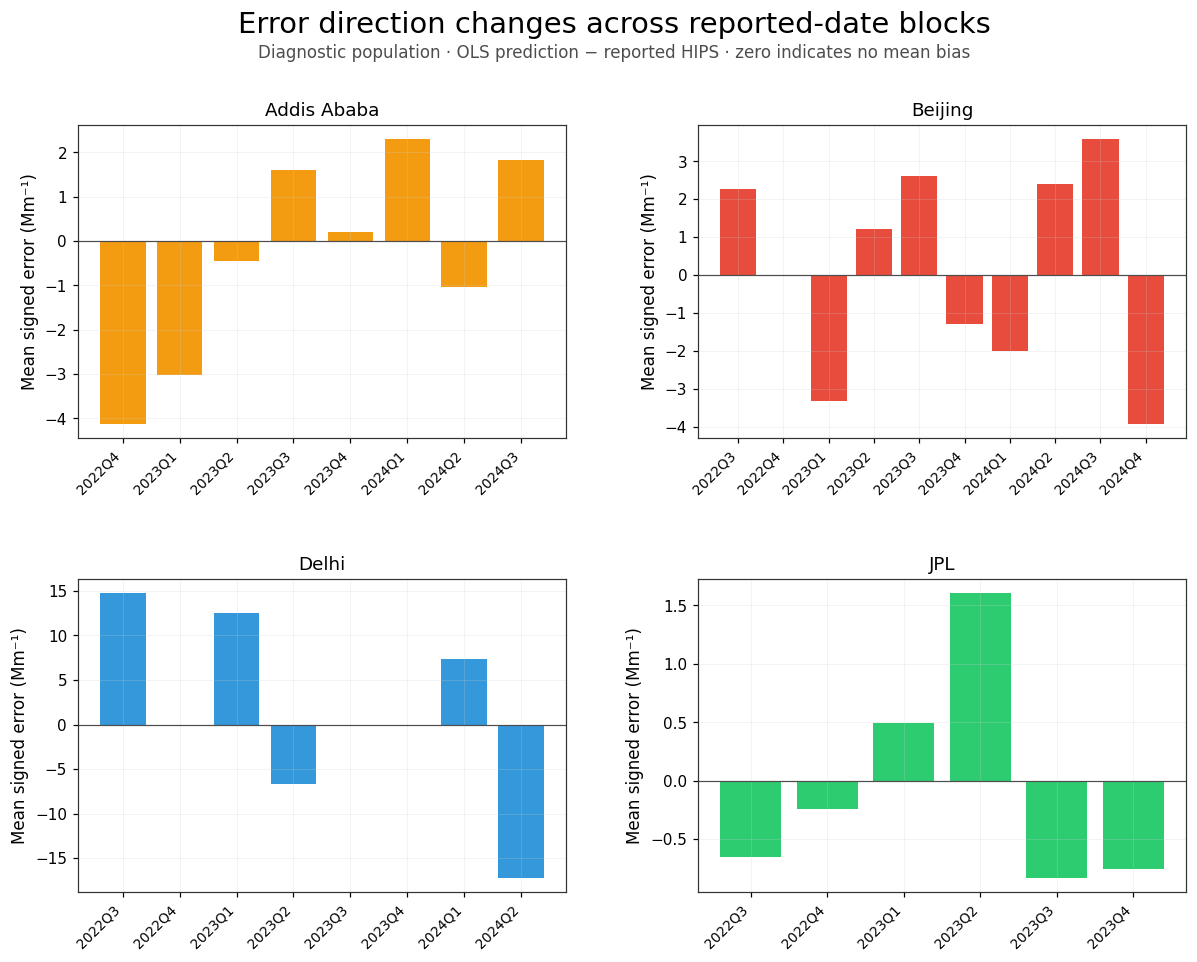

In [4]:
fig = charts.bias_blocks(b)
display(fig)
plt.close(fig)

**Notes.** Positive error means overprediction. Addis aggregate bias is near zero, but quarter biases range from −4.11 to +2.30 Mm⁻¹. Opposing errors cancel in the overall mean; residual time structure remains.

## Frozen denominator populations

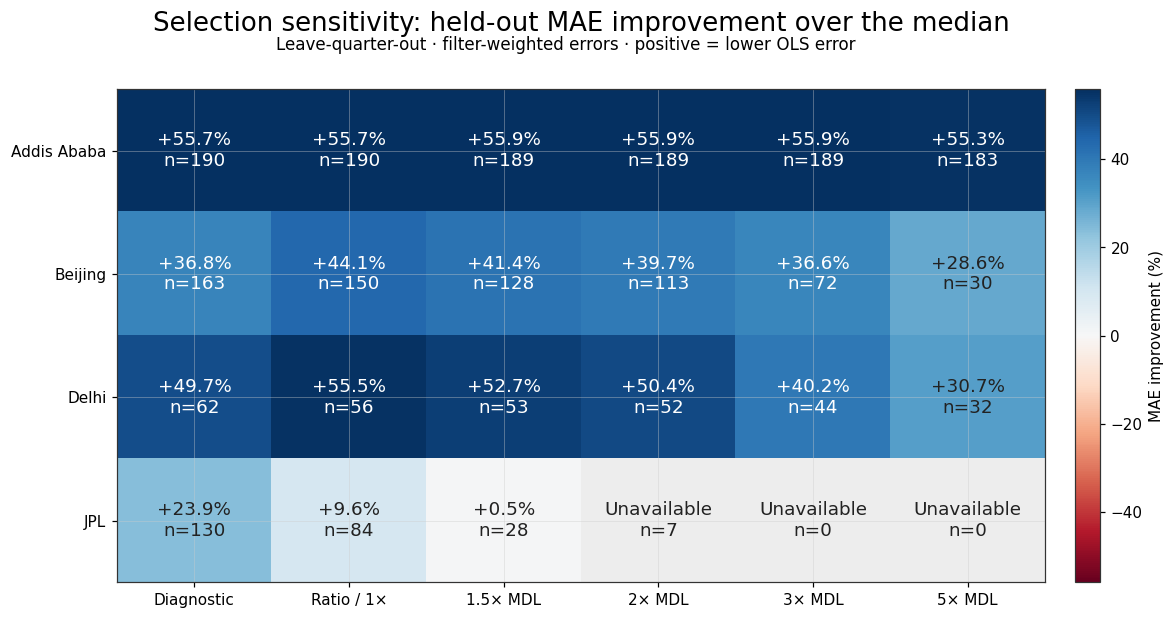

In [5]:
fig = charts.sensitivity(s,cohorts)
display(fig)
plt.close(fig)

**Notes.** Counts are full population membership; MAE uses only supported held-out folds. No threshold was selected from these errors. JPL retains 84 ratio filters and 28 at 1.5× MDL; improvements shrink to 9.6% and 0.5%. Its seven-point 2× population remains visible but cannot supply ten training filters. Addis 1.5×, 2× and 3× share the same 189 filters.

## One filter versus whole blocks

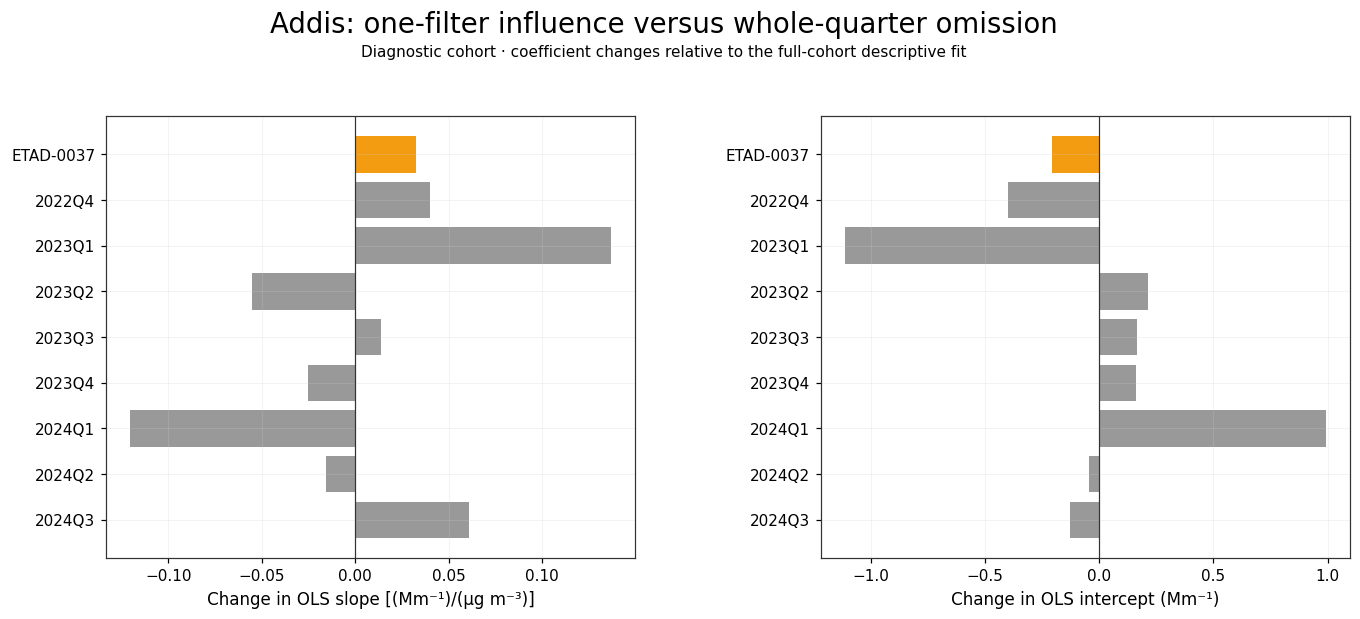

In [6]:
fig = charts.coefficients(b,c)
display(fig)
plt.close(fig)

**Notes.** The full-cohort OLS coefficients are descriptive references, not validation scores. ETAD-0037 omission changes slope by +0.033 and intercept by −0.206 Mm⁻¹. Whole-quarter omissions have wider coefficient changes. The filter stays in the baseline and exclusion registry.

## Held-out predictions

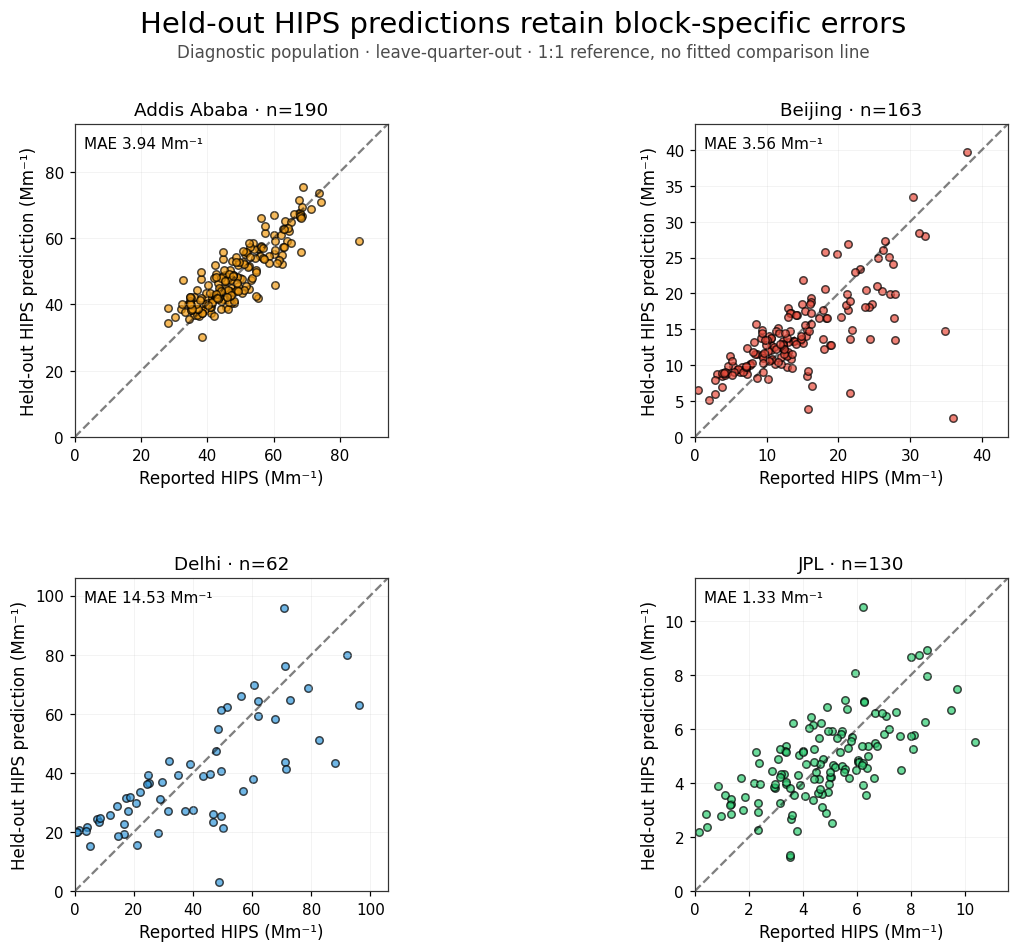

In [7]:
fig = charts.prediction_scatter(p)
display(fig)
plt.close(fig)

**Notes.** Every displayed prediction is generated with that filter’s quarter held out. The 1:1 line compares predicted and reported HIPS in the same units. No regression slope is fitted to this prediction-comparison plot. The FTIR predictor itself is not established as an independent reference.

## Later-period prediction

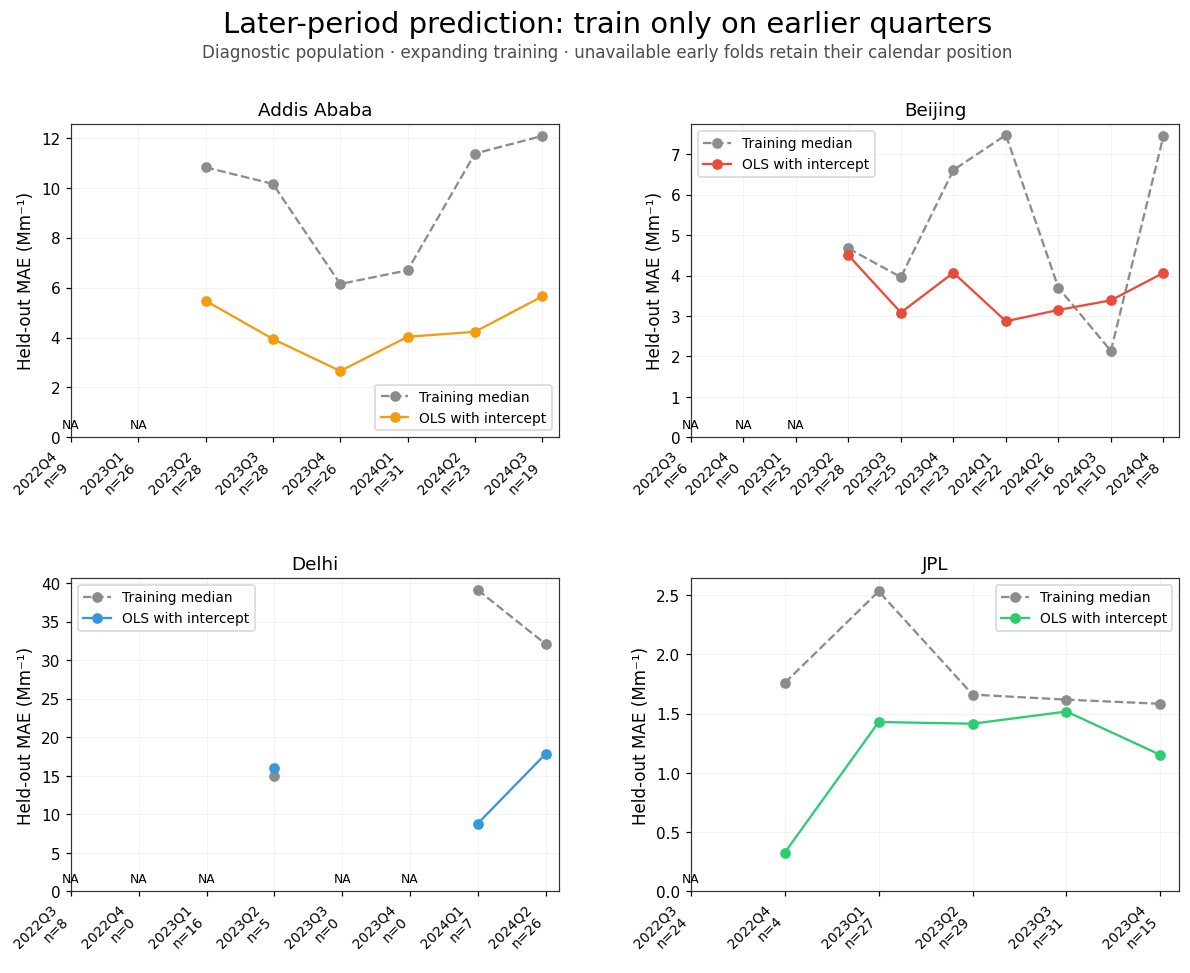

In [8]:
fig = charts.mae_blocks(b,'later_period')
display(fig)
plt.close(fig)

**Notes.** Only strictly earlier quarters enter training. Early unsupported folds remain unavailable. Addis evaluates 155 filters with MAE 4.27 versus 9.33 Mm⁻¹; mean error is +2.26. Delhi retains substantial negative bias (−15.30 Mm⁻¹), despite average improvement. The changed evaluated populations prevent a direct algorithm comparison with leave-quarter-out results.

## Training and test EC ranges

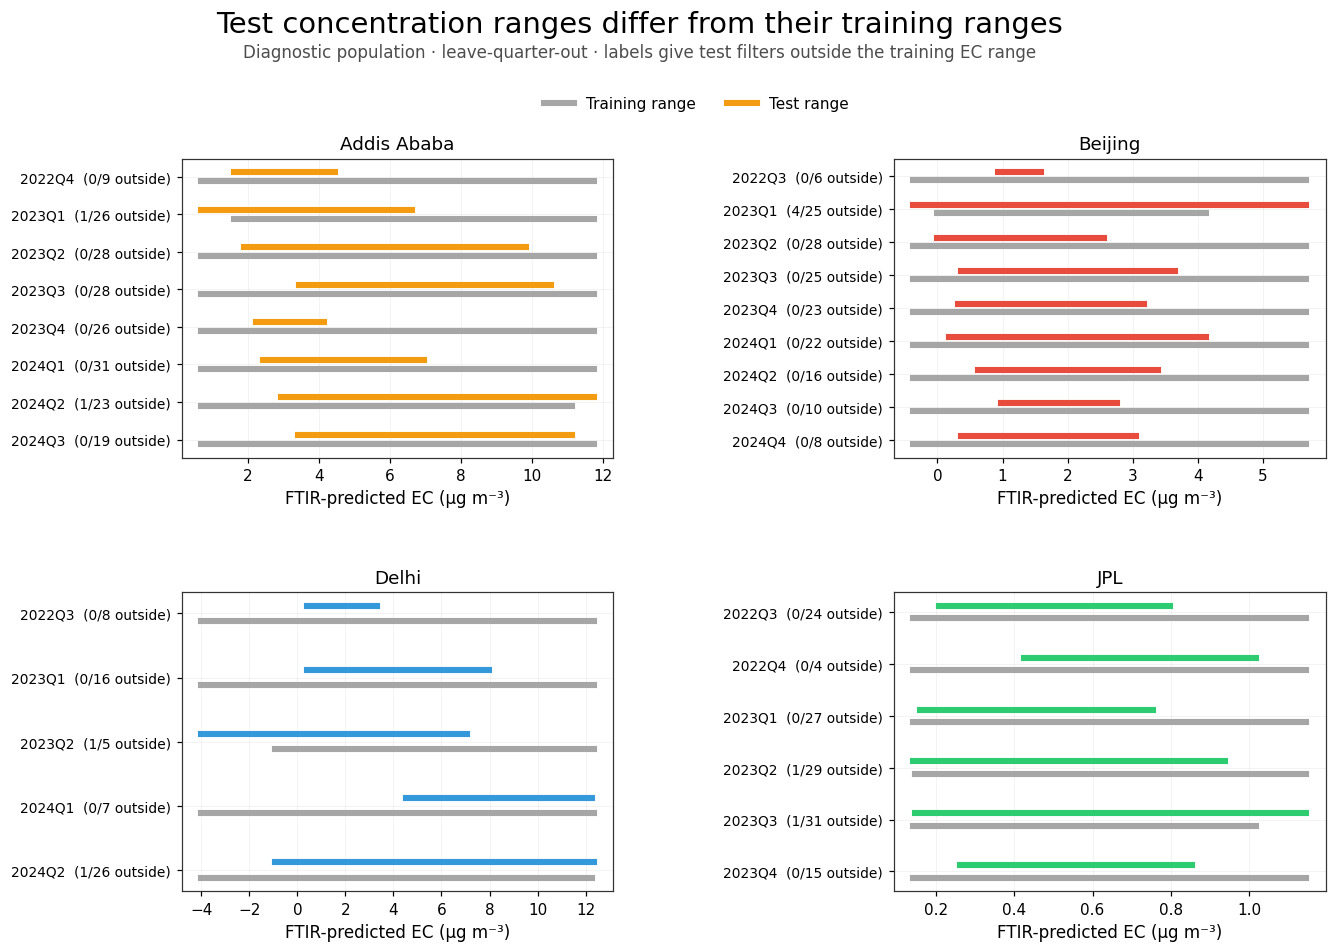

In [9]:
fig = charts.concentration_ranges(b)
display(fig)
plt.close(fig)

**Notes.** Extrapolation counts refer to test EC below the minimum or above the maximum training EC. Points are retained. Different concentration ranges can change prediction difficulty; a zero extrapolation count does not establish comparable distributions or precise EC measurements.

## Source-linked metadata

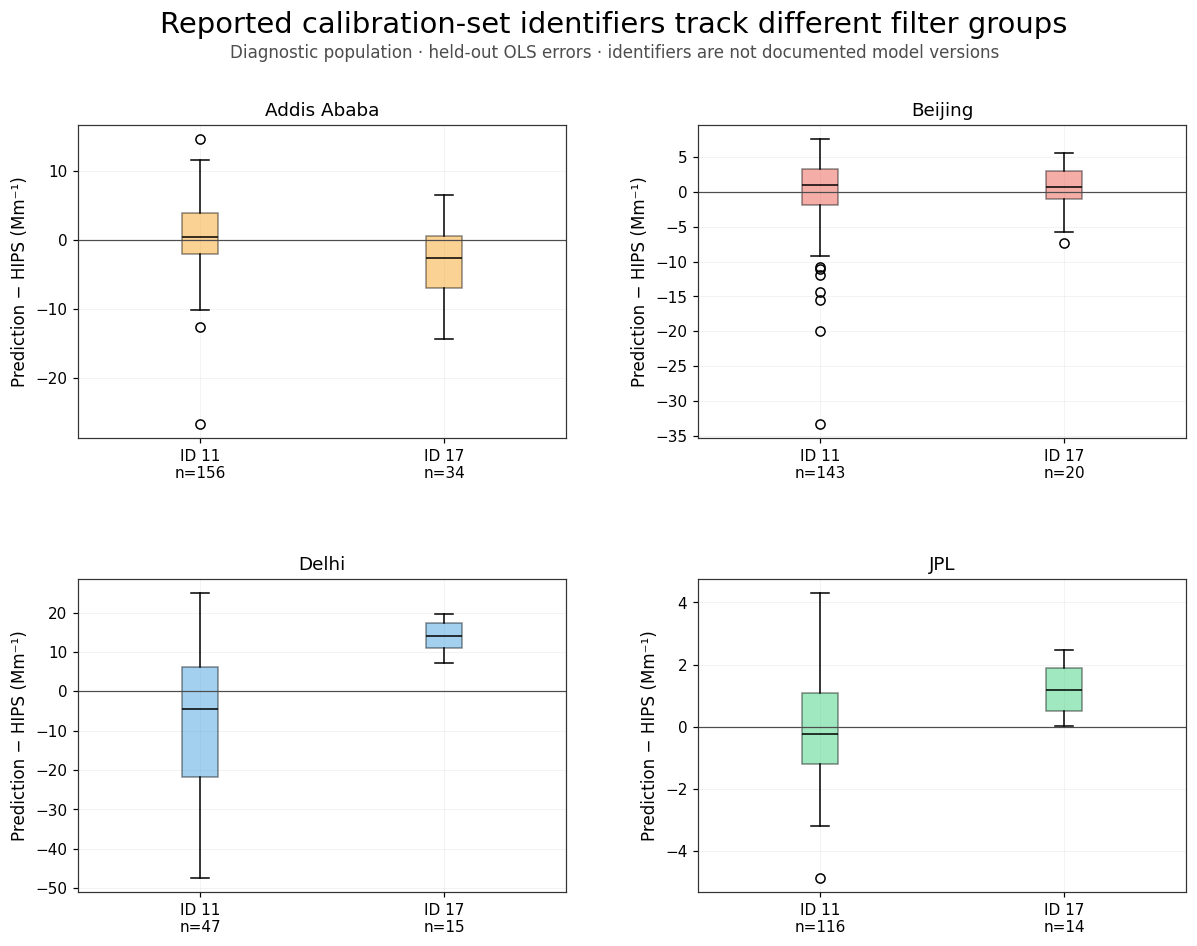

In [10]:
fig = charts.metadata_plot(p)
display(fig)
plt.close(fig)

**Notes.** CalibrationSetId values come from actual EC_ftir source rows. Addis ID 17 covers 34 early filters, through 22 March 2023; ID 11 covers 156 later filters, beginning 29 March. Date and identifier effects cannot be separated here. IDs are not documented FTIR model versions, LotId is not a confirmed batch, and ChemSpec method codes 217/218 are not used as substitutes.

## Errors on common filters

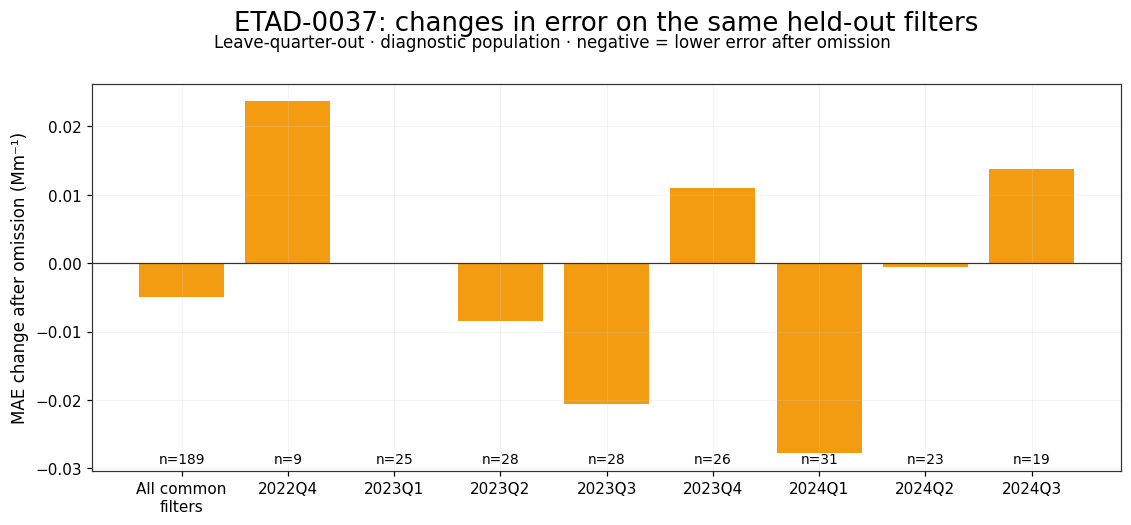

In [11]:
fig = charts.paired_plot(inf)
display(fig)
plt.close(fig)

**Notes.** The ETAD-0037 sensitivity compares the same 189 other filters. Primary MAE changes by only −0.0049 Mm⁻¹. Predictions in its own withheld quarter do not change because it was absent from training already. Later-period common-filter MAE worsens by +0.172 Mm⁻¹ after omission, concentrated in the first evaluated later block.

## Separate evidence actions

The ChemSpec upstream question packet is drafted, not sent. The candidate-specific SQLite lookup recovered 1,440 session-46 records for USPA-0257 and matched all staged timestamp/datum IDs. Verified active-operation evidence, scoped correction/quality history and source-backed eBC units remain missing; no verified interval mean is reported.

The [full report](/Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/tables/filter_relationship_stability/filter_relationship_stability_report.md), prediction parquet, block CSV, original measurement links and manifests are regenerated by the workflow. The specification was frozen before fitting; original FTIR training independence remains unresolved.